# 第 9 章 · Skip-gram 代码实验

本页从上下文窗口训练一个小型 Skip-gram。读者先看中心词-上下文样本，再看训练后的最近邻和 king - man + woman 类比。

[章节网页](../ch9.html)

## 运行内容

- 生成中心词-上下文样本
- 训练 Skip-gram
- 计算最近邻和类比

## 0. 上下文样本

Skip-gram 的训练样本来自同一句话附近的词。中心词负责预测窗口内的上下文词。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# Skip-gram 训练数据：中心词预测窗口内的上下文词。
sentences = [
    "king queen royal palace crown".split(),
    "king prince royal palace crown".split(),
    "queen princess royal palace crown".split(),
    "man king prince royal leader".split(),
    "woman queen princess royal leader".split(),
    "man woman family adult person".split(),
    "boy girl family young person".split(),
    "apple orange banana fruit market".split(),
    "orange banana fruit market sweet".split(),
]
training_sentences = sentences * 20
vocab_words = sorted({word for sent in training_sentences for word in sent})
word_to_id = {word: idx for idx, word in enumerate(vocab_words)}

window = 2
skipgram_pairs = []
for sent in training_sentences:
    ids = [word_to_id[word] for word in sent]
    for center_pos, center_id in enumerate(ids):
        left = max(0, center_pos - window)
        right = min(len(ids), center_pos + window + 1)
        for context_pos in range(left, right):
            if context_pos != center_pos:
                skipgram_pairs.append((center_id, ids[context_pos]))

display(pd.DataFrame({
    "句子数": [len(training_sentences)],
    "词表大小": [len(vocab_words)],
    "窗口大小": [window],
    "训练样本对": [len(skipgram_pairs)],
}))
display(pd.DataFrame(skipgram_pairs[:12], columns=["中心词编号", "上下文词编号"]).assign(
    中心词=lambda df: df["中心词编号"].map(lambda idx: vocab_words[idx]),
    上下文词=lambda df: df["上下文词编号"].map(lambda idx: vocab_words[idx]),
)[["中心词", "上下文词"]])

,句子数,词表大小,窗口大小,训练样本对
0,180,22,2,2520


,中心词,上下文词
0,king,queen
1,king,royal
2,queen,king
3,queen,royal
4,queen,palace
5,royal,king
6,royal,queen
7,royal,palace
8,royal,crown
9,palace,queen


## 1. 训练与类比

训练后，相似上下文会让词向量靠近；类比向量展示一种方向差能否从 king 迁移到 queen。

In [3]:
# 用完整 softmax 训练小型 Skip-gram，并记录损失。
rng = np.random.default_rng(9)
vocab_size = len(vocab_words)
embed_dim = 8
W_in = rng.normal(0, 0.05, size=(vocab_size, embed_dim))
W_out = rng.normal(0, 0.05, size=(vocab_size, embed_dim))
lr = 0.04
loss_rows = []

def stable_softmax(scores):
    scores = scores - scores.max()
    probs = np.exp(scores)
    return probs / probs.sum()

for epoch in range(1, 501):
    rng.shuffle(skipgram_pairs)
    total_loss = 0.0
    for center_id, context_id in skipgram_pairs:
        center_vec = W_in[center_id].copy()
        probs = stable_softmax(center_vec @ W_out.T)
        total_loss += -np.log(probs[context_id] + 1e-12)
        grad = probs
        grad[context_id] -= 1
        W_in[center_id] -= lr * (grad @ W_out)
        W_out -= lr * np.outer(grad, center_vec)
    if epoch in {1, 20, 50, 100, 200, 500}:
        loss_rows.append({"训练轮次": epoch, "平均负对数似然": total_loss / len(skipgram_pairs)})

word_embedding = normalize((W_in + W_out) / 2)
sim = cosine_similarity(word_embedding)
loss_df = pd.DataFrame(loss_rows)

nearest_rows = []
for word in ["king", "queen", "man", "woman", "apple", "fruit"]:
    idx = word_to_id[word]
    order = np.argsort(sim[idx])[::-1]
    neighbors = [vocab_words[j] for j in order if j != idx][:4]
    nearest_rows.append({"词": word, "最近邻": " / ".join(neighbors), "最高相似度": sim[idx, order[1]]})

analogy_vec = word_embedding[word_to_id["king"]] - word_embedding[word_to_id["man"]] + word_embedding[word_to_id["woman"]]
analogy_vec = normalize(analogy_vec.reshape(1, -1))
analogy_scores = cosine_similarity(analogy_vec, word_embedding)[0]
for source_word in ["king", "man", "woman"]:
    analogy_scores[word_to_id[source_word]] = -999
analogy_df = pd.DataFrame({
    "候选词": vocab_words,
    "king - man + woman 相似度": np.round(analogy_scores, 3),
}).sort_values("king - man + woman 相似度", ascending=False).head(8)

display(loss_df.round(3))
display(pd.DataFrame(nearest_rows).round(3))
display(analogy_df)

,训练轮次,平均负对数似然
0,1,2.722
1,20,1.511
2,50,1.514
3,100,1.503
4,200,1.507
5,500,1.505


,词,最近邻,最高相似度
0,king,prince / leader / royal / man,0.981
1,queen,princess / royal / leader / palace,0.993
2,man,king / woman / prince / family,0.833
3,woman,adult / man / family / queen,0.849
4,apple,orange / banana / fruit / market,0.980
5,fruit,market / banana / orange / sweet,0.993


,候选词,king - man + woman 相似度
17,queen,0.979
16,princess,0.974
18,royal,0.878
9,leader,0.869
13,palace,0.834
4,crown,0.722
15,prince,0.697
0,adult,0.434


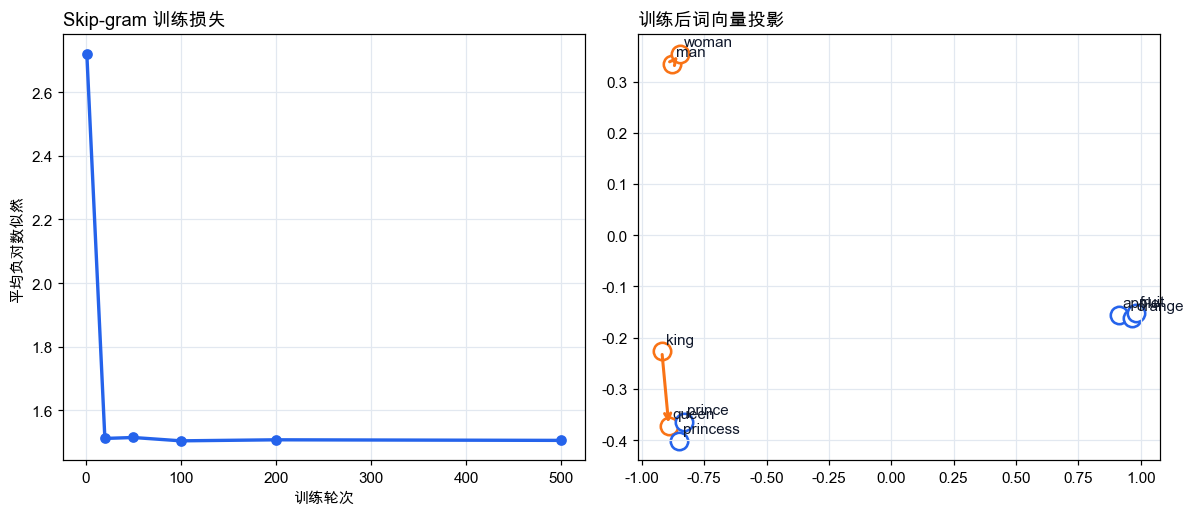

In [4]:
# 用二维投影查看训练后的语义空间。
svd = TruncatedSVD(n_components=2, random_state=0)
emb_2d = svd.fit_transform(word_embedding)
important_words = ["king", "queen", "man", "woman", "prince", "princess", "apple", "orange", "fruit"]

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8))
axes[0].plot(loss_df["训练轮次"], loss_df["平均负对数似然"], marker="o", color="#2563eb", linewidth=2.2)
axes[0].set_title("Skip-gram 训练损失", loc="left", fontweight="bold")
axes[0].set_xlabel("训练轮次")
axes[0].set_ylabel("平均负对数似然")
axes[0].grid(True, color="#e2e8f0", linewidth=0.8)

for word in important_words:
    idx = word_to_id[word]
    color = "#f97316" if word in {"king", "queen", "man", "woman"} else "#2563eb"
    axes[1].scatter(emb_2d[idx, 0], emb_2d[idx, 1], s=130, color="#ffffff", edgecolor=color, linewidth=1.7)
    axes[1].text(emb_2d[idx, 0] + 0.015, emb_2d[idx, 1] + 0.015, word, color="#0f172a")
axes[1].annotate("", xy=emb_2d[word_to_id["queen"]], xytext=emb_2d[word_to_id["king"]], arrowprops={"arrowstyle": "->", "color": "#f97316", "lw": 2})
axes[1].annotate("", xy=emb_2d[word_to_id["woman"]], xytext=emb_2d[word_to_id["man"]], arrowprops={"arrowstyle": "->", "color": "#f97316", "lw": 2})
axes[1].set_title("训练后词向量投影", loc="left", fontweight="bold")
axes[1].grid(True, color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()